In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [19]:
df = pd.read_csv("boston.csv")

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [20]:
X = df.drop("MEDV", axis=1)   # Features
y = df["MEDV"]                # Target

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
x_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

In [23]:
y_scaler = StandardScaler()

y_train = y_scaler.fit_transform(y_train.values.reshape(-1,1))
y_test = y_scaler.transform(y_test.values.reshape(-1,1))

In [24]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    Dense(16, activation='relu'),
    
    Dense(1)
])

In [25]:
model.compile(
    optimizer='rmsprop',
    loss='mse',
    metrics=['mae']
)

In [26]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [27]:
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.0970 - mae: 0.7788 - val_loss: 0.7257 - val_mae: 0.6134
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7869 - mae: 0.6350 - val_loss: 0.5585 - val_mae: 0.5329
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6226 - mae: 0.5645 - val_loss: 0.4486 - val_mae: 0.4652
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5680 - mae: 0.5448 - val_loss: 0.3742 - val_mae: 0.4147
Epoch 5/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4927 - mae: 0.5037 - val_loss: 0.3297 - val_mae: 0.3748
Epoch 6/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4133 - mae: 0.4572 - val_loss: 0.2948 - val_mae: 0.3391
Epoch 7/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3562 - mae: 0.4120 - val_loss: 0.2738 - val_mae: 0.3260
Epoch 8/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3691 - mae: 0.4268 - val_loss: 0.2780 - val_mae: 0.3258
Epoch 9/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.30

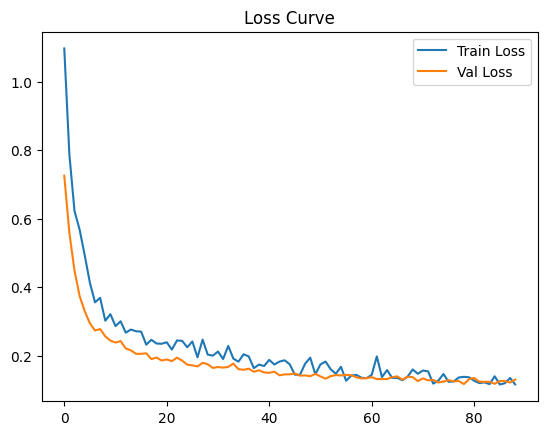

In [28]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

In [29]:
loss, mae = model.evaluate(X_test, y_test)

print("Scaled Loss (MSE):", loss)
print("Scaled MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1492 - mae: 0.2384
Scaled Loss (MSE): 0.14920610189437866
Scaled MAE: 0.23835502564907074


In [30]:
y_pred_scaled = model.predict(X_test)

# Convert back to original values
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_test_actual = y_scaler.inverse_transform(y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


In [31]:
for i in range(5):
    print(f"Actual: {y_test_actual[i][0]:.2f}, Predicted: {y_pred[i][0]:.2f}")

Actual: 23.60, Predicted: 27.19
Actual: 32.40, Predicted: 33.94
Actual: 13.60, Predicted: 16.66
Actual: 22.80, Predicted: 22.64
Actual: 16.10, Predicted: 14.91


In [32]:
r2 = r2_score(y_test_actual, y_pred)
print("R2 Score:", r2)

R2 Score: 0.8232459260237674


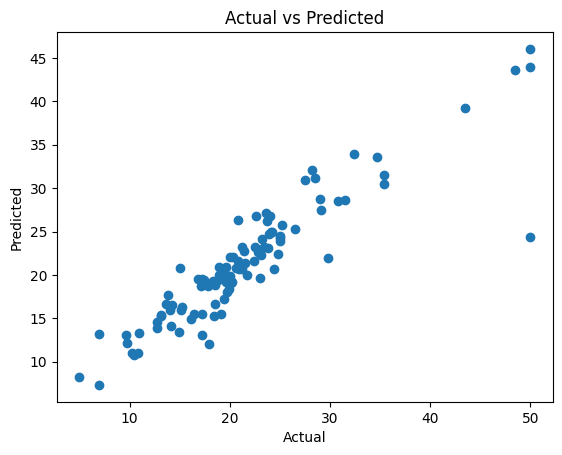

In [33]:
plt.scatter(y_test_actual, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()